In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
seed = 42  # Choose any seed value
np.random.seed(seed)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)

# Read in data for second innings
it20_data = pd.read_csv('archive/ball_by_ball_it20.csv')
innings2 = it20_data.loc[it20_data['Innings'] == 2]

# Drop the last row for each run chase as the result is known
innings2 = innings2.drop(innings2[innings2['Balls Remaining'] == 0].index)
innings2.reset_index(drop=True, inplace=True)

print('No of Matches: ', innings2['Match ID'].nunique())
print('Data Frame Length: ', len(innings2.index))

innings2.head()

No of Matches:  1842
Data Frame Length:  199749


,Unnamed: 0,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,Non Striker,Bowler,Batter Runs,Extra Runs,Runs From Ball,Ball Rebowled,Extra Type,Wicket,Method,Player Out,Innings Runs,Innings Wickets,Target Score,Runs to Get,Balls Remaining,Winner,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
0,124,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,1,Q de Kock,RR Hendricks,AJ Hosein,4,0,4,0,[],0,NaN,NaN,4,0,259,255.0,119,South Africa,1,4,0,1,0,NaN,NaN,4,1
1,125,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,2,Q de Kock,RR Hendricks,AJ Hosein,4,0,4,0,[],0,NaN,NaN,8,0,259,251.0,118,South Africa,1,8,0,2,0,NaN,NaN,4,1
2,126,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,3,Q de Kock,RR Hendricks,AJ Hosein,0,0,0,0,[],0,NaN,NaN,8,0,259,251.0,117,South Africa,1,8,0,3,0,NaN,NaN,0,1
3,127,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,4,Q de Kock,RR Hendricks,AJ Hosein,0,0,0,0,[],0,NaN,NaN,8,0,259,251.0,116,South Africa,1,8,0,4,0,NaN,NaN,0,1
4,128,1339605,2023-03-26,SuperSport Park,West Indies,South Africa,2,1,5,Q de Kock,RR Hendricks,AJ Hosein,1,0,1,0,[],0,NaN,NaN,9,0,259,250.0,115,South Africa,1,9,0,5,0,NaN,NaN,1,1


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define the features of the model
features = ['Runs From Ball','Innings Runs', 'Innings Wickets', 'Balls Remaining', 'Target Score', 'Total Batter Runs','Total Non Striker Runs','Batter Balls Faced','Non Striker Balls Faced']

# Step 2: Set the cutoff date
cutoff_date = '2018-01-01'

# Step 3: Split the data into training and test sets based on the cutoff date
train_data = innings2[innings2['Date'] < cutoff_date]
test_data = innings2[innings2['Date'] >= cutoff_date]

# Step 4: Select the relevant features for X and the target variable for y
X_train = train_data[features].copy()
y_train = train_data['Chased Successfully']
X_test = test_data[features].copy()
y_test = test_data['Chased Successfully']

# Quick diagnostics to help debug common runtime errors
print('X_train shape:', X_train.shape)
print('X_train dtypes:\n', X_train.dtypes)
print('Missing values in X_train:\n', X_train.isnull().sum())

# Fill numeric missing values with the training-column medians (safe default)
num_medians = X_train.median(numeric_only=True)
# Coerce non-numeric columns to numeric (will become NaN) then fill with medians and finally fill any remaining NaNs with 0
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(num_medians).fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(num_medians).fillna(0)

# Step 5: Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train shape: (62335, 9)
X_train dtypes:
 Runs From Ball             int64
Innings Runs               int64
Innings Wickets            int64
Balls Remaining            int64
Target Score               int64
Total Batter Runs          int64
Total Non Striker Runs     int64
Batter Balls Faced         int64
Non Striker Balls Faced    int64
dtype: object
Missing values in X_train:
 Runs From Ball             0
Innings Runs               0
Innings Wickets            0
Balls Remaining            0
Target Score               0
Total Batter Runs          0
Total Non Striker Runs     0
Batter Balls Faced         0
Non Striker Balls Faced    0
dtype: int64


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

random_state = 42

# Shortlisted models with a small pipeline that ensures reproducible preprocessing
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(random_state=random_state, max_iter=1000)),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(random_state=random_state)),
    'Gradient Boosting': make_pipeline(StandardScaler(), GradientBoostingClassifier(random_state=random_state)),
}

# Evaluate with cross-validation on training data to get robust estimates
n_samples = len(y_train)
cv = min(5, n_samples) if n_samples >= 2 else 0
for name, pipeline in models.items():
    if cv < 2:
        print(f"Not enough training samples ({n_samples}) for cross-validation. Skipping CV for {name}.")
        pipeline.fit(X_train, y_train)
        train_score = pipeline.score(X_train, y_train)
        print(f"{name} training accuracy (no CV): {train_score:.3f}")
    else:
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
        print(f'{name} CV accuracy: {scores.mean():.3f} (±{scores.std():.3f})')

# Fit final chosen model on full training set (example: Logistic Regression)
final_model = models['Logistic Regression']
final_model.fit(X_train, y_train)
print('Final model trained: Logistic Regression')

Logistic Regression CV accuracy: 0.796 (±0.028)
Random Forest CV accuracy: 0.747 (±0.024)
Gradient Boosting CV accuracy: 0.765 (±0.030)
Final model trained: Logistic Regression


Accuracy: 0.8264805623881119


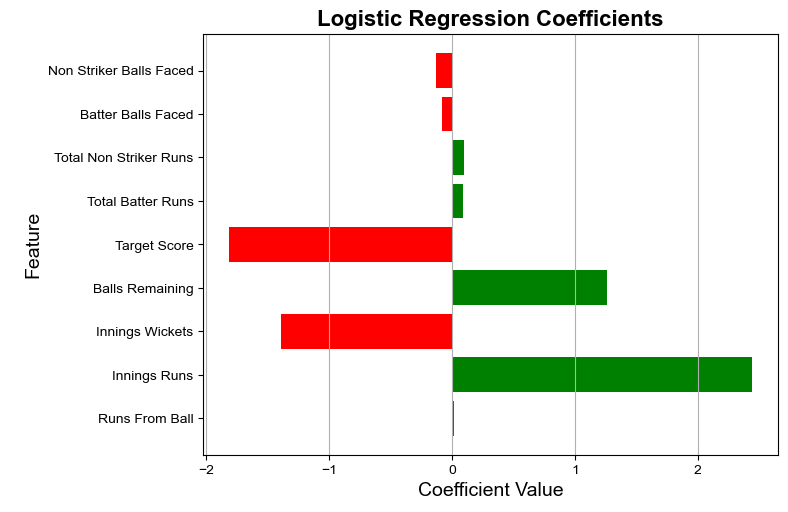

In [11]:
# Train the logistic regression model
model = LogisticRegression(C=1)
model.fit(X_train, y_train)

# Evaluate the model on the testing set
LR_score = model.score(X_test, y_test)
# Print the accuracy
print("Accuracy:", LR_score)

#Get the coefficients
coefs = model.coef_[0]

# Create horizontal bar plot with colors
colors = ['green' if c > 0 else 'red' for c in coefs]
fig, ax = plt.subplots()
ax.barh(features, coefs, color=colors)

# Adjust layout and font
fig.set_size_inches(8, 5)
plt.tight_layout(pad=2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Add title and axis labels
ax.set_title('Logistic Regression Coefficients', fontsize=16, fontweight='bold')
ax.set_xlabel('Coefficient Value', fontsize=14)
ax.set_ylabel('Feature', fontsize=14)

# Add horizontal grid lines
ax.xaxis.grid(True)

# Show plot
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

df = innings2
phases = ['Powerplay', 'Middle Overs', 'Final Overs']
for i, phase in enumerate(phases):
    print('Phase of Play: ', phase)
    if i == 0:
        data = df[df['Balls Remaining'] > 84]
    elif i == 1:
        data = df[(df['Balls Remaining'] > 30) & (df['Balls Remaining'] <= 84)]
    else:
        data = df[df['Balls Remaining'] <= 30]

    # Step 2: Set the cutoff date
    cutoff_date = '2018-01-01'

    # Step 3: Split the data into training and test sets based on the cutoff date
    train_data = data[data['Date'] < cutoff_date]
    test_data = data[data['Date'] >= cutoff_date]

    # Step 4: Select the relevant features for X and the target variable for y
    X_train = train_data[features].copy()
    y_train = train_data['Chased Successfully']
    X_test = test_data[features].copy()
    y_test = test_data['Chased Successfully']

    # Coerce numeric, fill medians from training set, and scale
    num_medians = X_train.median(numeric_only=True)
    X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(num_medians).fillna(0)
    X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(num_medians).fillna(0)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train and evaluate a simple logistic regression for this phase
    model = LogisticRegression(C=1, max_iter=1000)
    model.fit(X_train, y_train)
    LR_score = model.score(X_test, y_test)
    print(f"Accuracy of {phase} Classifier: {LR_score:.3f}")

Phase of Play:  Powerplay
Accuracy of Powerplay Classifier: 0.769
Phase of Play:  Middle Overs
Accuracy of Middle Overs Classifier: 0.843
Phase of Play:  Final Overs
Accuracy of Final Overs Classifier: 0.915
